In [1]:
import os
import glob
import random
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from PIL import Image
from collections import Counter

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import to_categorical

print("imports ok")

imports ok


In [2]:
# Configuration générale
BASE_DIR = "brain-tumor-mri-dataset"
IMG_SIZE = (256, 256)
CLASSES  = ['glioma', 'meningioma', 'notumor', 'pituitary']
SEED     = 42

random.seed(SEED)
np.random.seed(SEED)

print("Configuration :")
print(f"  Dataset : {BASE_DIR}")
print(f"  Taille images : {IMG_SIZE}")
print(f"  Classes : {CLASSES}")

Configuration :
  Dataset : brain-tumor-mri-dataset
  Taille images : (256, 256)
  Classes : ['glioma', 'meningioma', 'notumor', 'pituitary']


In [3]:
# Compter les images par classe et par split
print("Nombre d'images par classe :\n")

total = 0
for split in ['Training', 'Testing']:
    print(f"--- {split} ---")
    for cls in CLASSES:
        folder = os.path.join(BASE_DIR, split, cls)
        n = len(os.listdir(folder))
        total += n
        print(f"  {cls} : {n} images")
    print()

print(f"Total : {total} images")

Nombre d'images par classe :

--- Training ---
  glioma : 1400 images
  meningioma : 1400 images
  notumor : 1400 images
  pituitary : 1400 images

--- Testing ---
  glioma : 400 images
  meningioma : 400 images
  notumor : 400 images
  pituitary : 400 images

Total : 7200 images


**Observation :** Le dataset est parfaitement équilibré — 1400 images par classe en training et 400 en testing. 
Pas besoin de techniques de rééquilibrage (oversampling, class weights...).
Total : 7200 images.

In [4]:
# Chargement des images
X_train, y_train = [], []
X_test, y_test   = [], []

for cls in CLASSES:
    # Training
    folder = os.path.join(BASE_DIR, 'Training', cls)
    for f in os.listdir(folder):
        img = cv2.imread(os.path.join(folder, f), cv2.IMREAD_GRAYSCALE)
        if img is None:
            continue
        img = cv2.resize(img, IMG_SIZE)
        X_train.append(img)
        y_train.append(cls)
    
    # Testing
    folder = os.path.join(BASE_DIR, 'Testing', cls)
    for f in os.listdir(folder):
        img = cv2.imread(os.path.join(folder, f), cv2.IMREAD_GRAYSCALE)
        if img is None:
            continue
        img = cv2.resize(img, IMG_SIZE)
        X_test.append(img)
        y_test.append(cls)

X_train = np.array(X_train)
y_train = np.array(y_train)
X_test  = np.array(X_test)
y_test  = np.array(y_test)

print(f"X_train shape : {X_train.shape}")
print(f"X_test shape  : {X_test.shape}")
print(f"y_train shape : {y_train.shape}")

X_train shape : (5600, 256, 256)
X_test shape  : (1600, 256, 256)
y_train shape : (5600,)


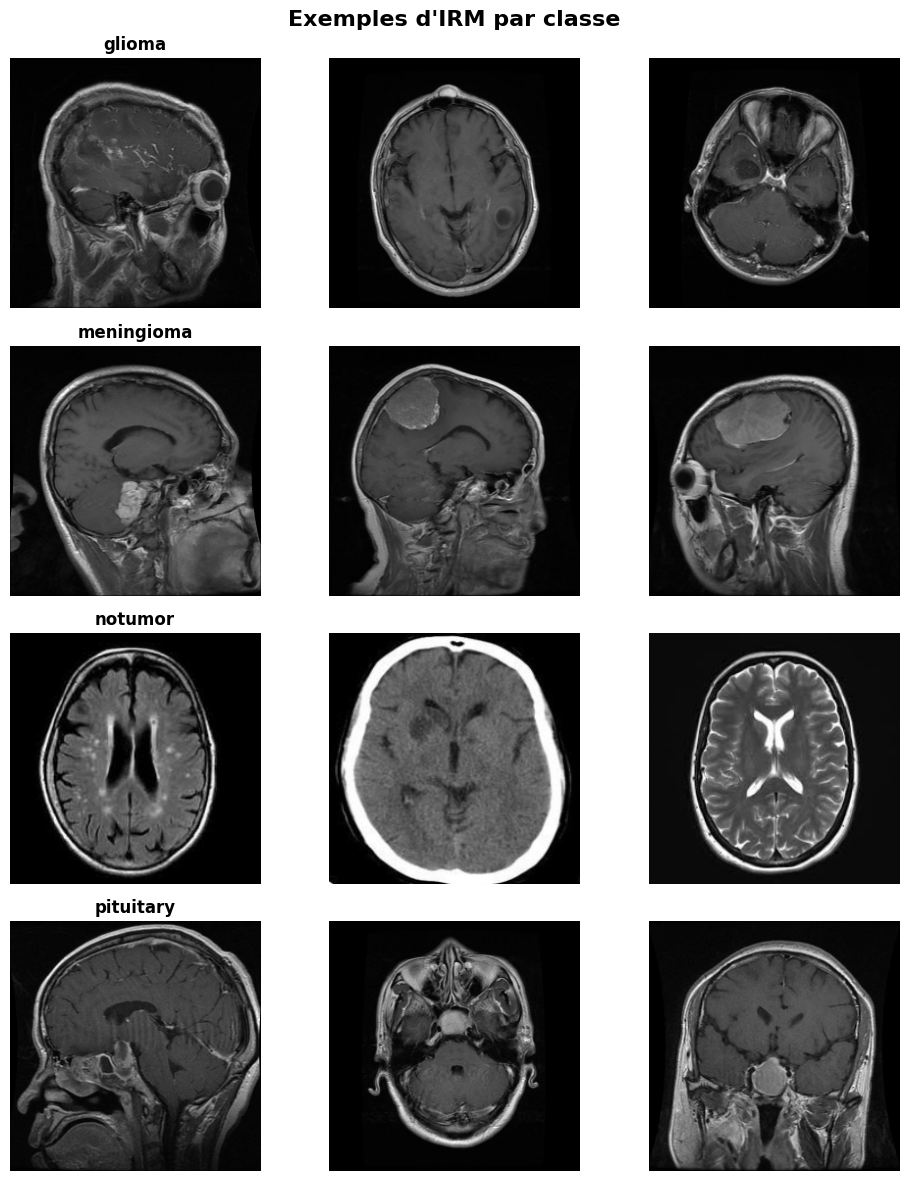

In [5]:
# Afficher 3 exemples par classe
fig, axes = plt.subplots(4, 3, figsize=(10, 12))
fig.suptitle("Exemples d'IRM par classe", fontsize=16, fontweight='bold')

for i, cls in enumerate(CLASSES):
    indices = np.where(y_train == cls)[0]
    for j in range(3):
        idx = random.choice(indices)
        axes[i, j].imshow(X_train[idx], cmap='gray')
        axes[i, j].axis('off')
        if j == 0:
            axes[i, j].set_title(cls, fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

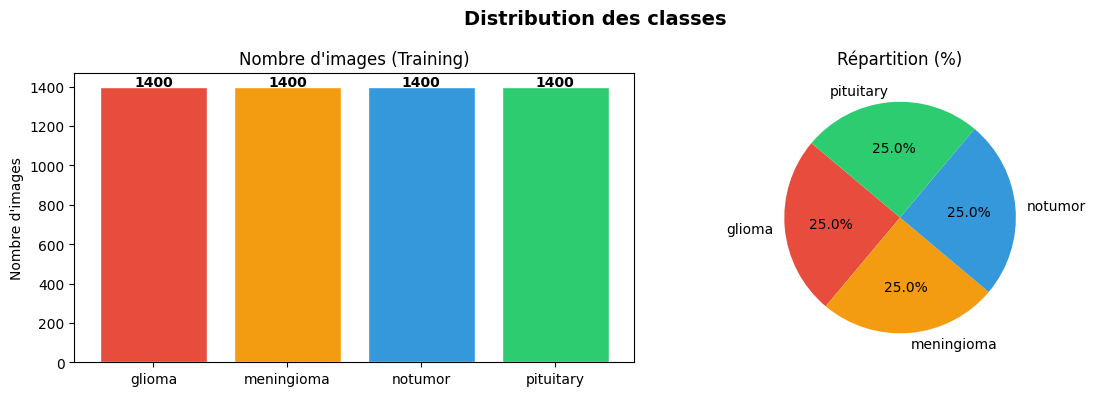

In [6]:
 # Distribution des classes
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Distribution des classes", fontsize=14, fontweight='bold')

# Compter
classes_train = pd.Series(y_train).value_counts()

# Barplot
ax1.bar(classes_train.index, classes_train.values, 
        color=['#E74C3C','#F39C12','#3498DB','#2ECC71'],
        edgecolor='white')
ax1.set_title("Nombre d'images (Training)")
ax1.set_ylabel("Nombre d'images")
for i, v in enumerate(classes_train.values):
    ax1.text(i, v + 5, str(v), ha='center', fontweight='bold')

# Pie chart
ax2.pie(classes_train.values, labels=classes_train.index,
        colors=['#E74C3C','#F39C12','#3498DB','#2ECC71'],
        autopct='%1.1f%%', startangle=140)
ax2.set_title("Répartition (%)")

plt.tight_layout()
plt.show()

In [7]:
# Analyse des tailles originales des images
tailles = []

for cls in CLASSES:
    folder = os.path.join(BASE_DIR, 'Training', cls)
    for f in os.listdir(folder):
        img = cv2.imread(os.path.join(folder, f))
        if img is not None:
            h, w = img.shape[:2]
            tailles.append((w, h))

tailles_counter = Counter(tailles)
print(f"Nombre de tailles différentes : {len(tailles_counter)}")
print(f"\nTop 5 tailles les plus fréquentes :")
for taille, count in tailles_counter.most_common(5):
    print(f"  {taille[0]}x{taille[1]} pixels → {count} images")

largeurs = [t[0] for t in tailles]
hauteurs = [t[1] for t in tailles]
print(f"\nLargeur  : min={min(largeurs)}, max={max(largeurs)}, moy={int(np.mean(largeurs))}")
print(f"Hauteur  : min={min(hauteurs)}, max={max(hauteurs)}, moy={int(np.mean(hauteurs))}")

Nombre de tailles différentes : 381

Top 5 tailles les plus fréquentes :
  512x512 pixels → 4012 images
  225x225 pixels → 253 images
  630x630 pixels → 69 images
  201x251 pixels → 40 images
  236x236 pixels → 39 images

Largeur  : min=150, max=1375, moy=458
Hauteur  : min=168, max=1446, moy=462


Les images ont des tailles très variables (381 tailles différentes, 
de 150px à 1375px). Un redimensionnement à 256×256 est donc 
indispensable avant d'alimenter le modèle.

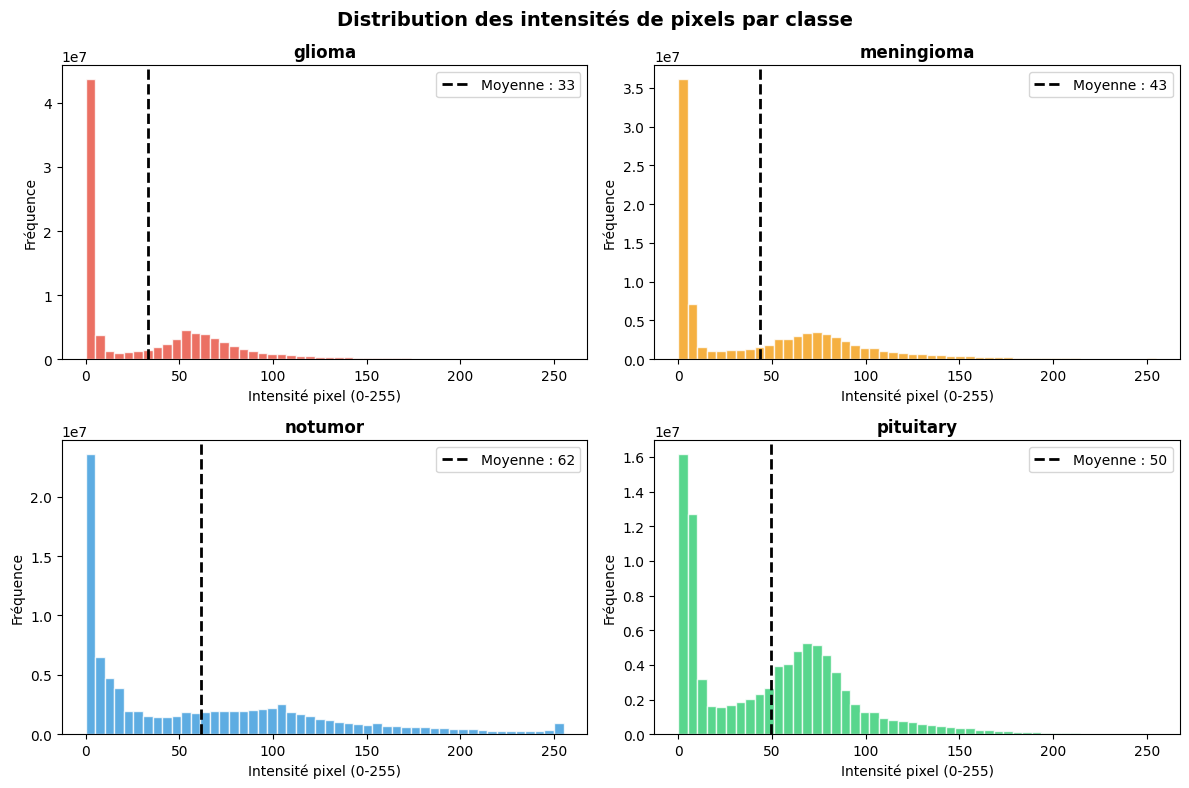

In [8]:
# Distribution des pixels par classe
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle("Distribution des intensités de pixels par classe", 
             fontsize=14, fontweight='bold')

couleurs = ['#E74C3C', '#F39C12', '#3498DB', '#2ECC71']

for i, (cls, couleur) in enumerate(zip(CLASSES, couleurs)):
    ax = axes[i//2, i%2]
    pixels = X_train[y_train == cls].flatten()
    ax.hist(pixels, bins=50, color=couleur, alpha=0.8, edgecolor='white')
    ax.set_title(f"{cls}", fontweight='bold')
    ax.set_xlabel("Intensité pixel (0-255)")
    ax.set_ylabel("Fréquence")
    ax.axvline(pixels.mean(), color='black', ls='--', lw=2, 
               label=f'Moyenne : {pixels.mean():.0f}')
    ax.legend()

plt.tight_layout()
plt.show()

In [9]:
# Normalisation : pixels entre 0 et 1
X_train_norm = X_train.astype('float32') / 255.0
X_test_norm  = X_test.astype('float32')  / 255.0

# Ajout du canal pour le CNN : (5600, 256, 256) -> (5600, 256, 256, 1)
X_train_norm = X_train_norm[..., np.newaxis]
X_test_norm  = X_test_norm[..., np.newaxis]

# Encodage des labels : string devient entier
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc  = le.transform(y_test)

print("Mapping des classes :")
for i, cls in enumerate(le.classes_):
    print(f"  {cls} → {i}")

print(f"\nAvant normalisation : min={X_train[0].min()}, max={X_train[0].max()}")
print(f"Après normalisation : min={X_train_norm[0].min():.1f}, max={X_train_norm[0].max():.1f}")
print(f"\nShape X_train : {X_train_norm.shape}")
print(f"Shape X_test  : {X_test_norm.shape}")

Mapping des classes :
  glioma → 0
  meningioma → 1
  notumor → 2
  pituitary → 3

Avant normalisation : min=0, max=244
Après normalisation : min=0.0, max=1.0

Shape X_train : (5600, 256, 256, 1)
Shape X_test  : (1600, 256, 256, 1)


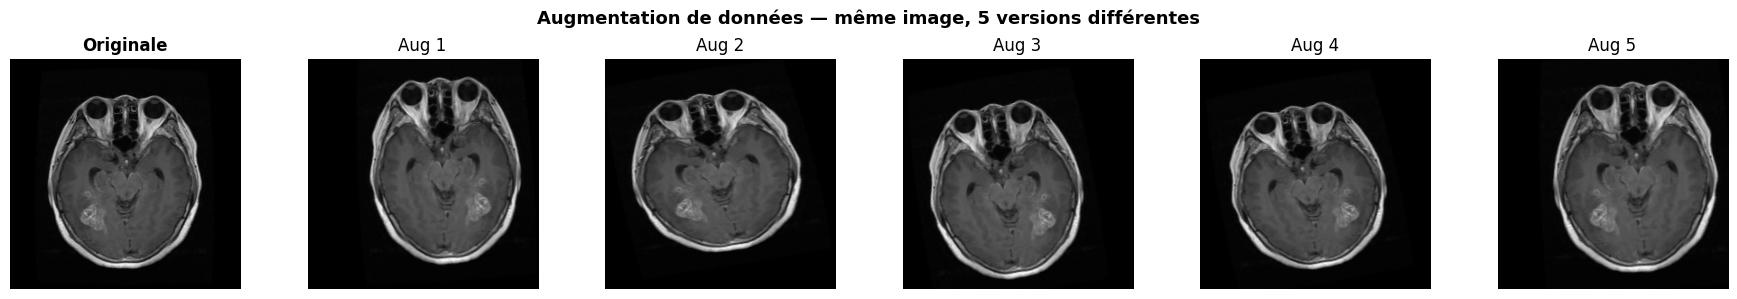

In [10]:
# Augmentation de données
datagen = ImageDataGenerator(
    rotation_range=15,        # rotation jusqu'à 15 degrés
    width_shift_range=0.1,    # décalage horizontal 10%
    height_shift_range=0.1,   # décalage vertical 10%
    zoom_range=0.1,           # zoom 10%
    horizontal_flip=True,     # retournement horizontal
    fill_mode='nearest'       # remplir les pixels manquants
)

# Visualiser l'effet de l'augmentation sur une image
sample = X_train_norm[0].reshape(1, 256, 256, 1)

fig, axes = plt.subplots(1, 6, figsize=(18, 3))
fig.suptitle("Augmentation de données — même image, 5 versions différentes", 
             fontsize=13, fontweight='bold')

# Image originale
axes[0].imshow(X_train_norm[0, :, :, 0], cmap='gray')
axes[0].set_title("Originale", fontweight='bold')
axes[0].axis('off')

# 5 versions augmentées
gen = datagen.flow(sample, batch_size=1)
for k in range(1, 6):
    img_aug = next(gen)[0, :, :, 0]
    axes[k].imshow(img_aug, cmap='gray')
    axes[k].set_title(f"Aug {k}")
    axes[k].axis('off')

plt.tight_layout()
plt.show()

In [11]:
# Split train / validation (80% / 20% du Training)
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_norm, y_train_enc,
    test_size=0.20,
    random_state=SEED,
    stratify=y_train_enc  
)

print(f"X_train  : {X_tr.shape}")
print(f"X_val    : {X_val.shape}")
print(f"X_test   : {X_test_norm.shape}")
print(f"\nDistribution dans X_train :")
for i, cls in enumerate(le.classes_):
    print(f"  {cls} : {(y_tr == i).sum()} images")

X_train  : (4480, 256, 256, 1)
X_val    : (1120, 256, 256, 1)
X_test   : (1600, 256, 256, 1)

Distribution dans X_train :
  glioma : 1120 images
  meningioma : 1120 images
  notumor : 1120 images
  pituitary : 1120 images
